# Test File
- Using [pybiber](https://pypi.org/project/pybiber/)

In [1]:
import pybiber as pb
import polars as pl

In [2]:
def get_mda(features):
    # Statistical analysis and visualization
    analyzer = pb.BiberAnalyzer(features, id_column=None)

    # Multi-Dimensional Analysis - see https://browndw.github.io/pybiber/biber-analyzer.html#comparison-with-bibers-original-dimensions for factor mapping
    '''
    Factor 1: Involved vs. Informational Production (negative to positive)
    Factor 2: Narrative vs. Non-narrative Concerns (negative to positive)
    Factor 3: Explicit vs. Situation-dependent Reference (negative to positive)
    Factor 4: Overt Expression of Persuasion (negative to positive)
    Factor 5: Abstract vs. Non-abstract Information (negative to positive)
    Factor 6: On-line Informational Elaboration (negative to positive)
    '''

    analyzer.mda_biber()
    print(analyzer.mda_summary)
    print(analyzer.mda_loadings)
    print(analyzer.mda_dim_scores)
    print(analyzer.mda_group_means)

    # Principal Component Analysis
    analyzer.pca()

    # Visualization options
    analyzer.mdaviz_screeplot()           # Eigenvalue plot
    analyzer.pcaviz_contrib()             # Feature contributions

In [3]:
temp_df = pl.read_csv('./getText/datasetsPrep/medicalDatasets/syntheticCareHomeNurseNotes.csv')

doc_id = [f't{num}' for num in list(range(1, len(temp_df)+1))]

df = pl.DataFrame({
    "doc_id": doc_id,
    "text": temp_df['text'].to_list()
})
# Light preprocessing to strip extra whitespace.
df = df.with_columns(
    pl.col("text")
    .str.strip_chars()
    .str.replace_all(r"\s+", " ")
    .str.replace_all(r"^\s*-\s*", "") # Remove dashes at the beginning of texts.
    .str.replace_all(r"^\s*\d+\.\s*", "") # Remove numbers in 1., 2., 3. format at the beginning of the text. 
    
)

pipeline = pb.PybiberPipeline(model="en_core_web_sm")
features, tokens = pipeline.run(df, return_tokens=True)
features = features.with_columns(pl.lit("all_docs").alias("category"))

Starting Processing corpus (5,783 items)...
Processing corpus: 50.0% (2,890/5,783) [31167.3 items/sec]
Starting spaCy processing (5,783 items)...
spaCy processing: 10.0% (578/5,783) [266.8 items/sec]
spaCy processing: 20.0% (1,156/5,783) [336.5 items/sec]
spaCy processing: 30.0% (1,734/5,783) [354.0 items/sec]
spaCy processing: 40.0% (2,312/5,783) [353.2 items/sec]
spaCy processing: 50.0% (2,890/5,783) [358.9 items/sec]
spaCy processing: 60.0% (3,468/5,783) [362.2 items/sec]
spaCy processing: 70.0% (4,046/5,783) [349.2 items/sec]
spaCy processing: 80.0% (4,624/5,783) [357.7 items/sec]
spaCy processing: 90.0% (5,202/5,783) [352.2 items/sec]
spaCy processing: 99.9% (5,780/5,783) [358.5 items/sec]
spaCy processing completed in 16.12s (5,783 items processed)


[INFO] Using TTR for f_43_type_token


Processing corpus: 99.9% (5,780/5,783) [347.8 items/sec]
Processing corpus completed in 16.62s (5,780 items processed)
Performance: Corpus processing completed in 16.62s


[INFO] All features normalized per 1000 tokens except: f_43_type_token and f_44_mean_word_length


In [4]:
features_df = features.to_pandas()
features_df

,doc_id,f_01_past_tense,f_02_perfect_aspect,f_03_present_tense,f_04_place_adverbials,f_05_time_adverbials,f_06_first_person_pronouns,f_07_second_person_pronouns,f_08_third_person_pronouns,f_09_pronoun_it,...,f_59_contractions,f_60_that_deletion,f_61_stranded_preposition,f_62_split_infinitive,f_63_split_auxiliary,f_64_phrasal_coordination,f_65_clausal_coordination,f_66_neg_synthetic,f_67_neg_analytic,category
0,t1,107.142857,0.000000,35.714286,0.0,35.714286,0.0,0.0,71.428571,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,all_docs
1,t10,0.000000,76.923077,115.384615,0.0,0.000000,0.0,0.0,115.384615,0.0,...,0.0,0.0,0.0,0.0,0.0,38.461538,0.000000,0.0,0.0,all_docs
2,t100,131.578947,0.000000,0.000000,0.0,0.000000,0.0,0.0,131.578947,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,26.315789,0.0,0.0,all_docs
3,t1000,0.000000,0.000000,62.500000,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,125.000000,0.000000,0.0,0.0,all_docs
4,t1001,0.000000,0.000000,55.555556,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,55.555556,0.000000,0.0,0.0,all_docs
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5778,t995,0.000000,47.619048,47.619048,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,142.857143,0.000000,0.0,0.0,all_docs
5779,t996,0.000000,0.000000,133.333333,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,all_docs
5780,t997,0.000000,47.619048,47.619048,0.0,0.000000,0.0,0.0,95.238095,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,all_docs
5781,t998,0.000000,0.000000,66.666667,0.0,0.000000,0.0,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,133.333333,0.000000,0.0,0.0,all_docs


INFO:pybiber.biber_analyzer:Zero-variance features retained (neutral scaling) in projection: ['f_07_second_person_pronouns', 'f_22_that_adj_comp', 'f_33_pied_piping', 'f_35_because', 'f_47_hedges', 'f_50_discourse_particles']
INFO:pybiber.biber_analyzer:Zero-variance features retained (neutral scaling) in PCA: ['f_07_second_person_pronouns', 'f_22_that_adj_comp', 'f_33_pied_piping', 'f_35_because', 'f_47_hedges', 'f_50_discourse_particles']


shape: (7, 6)
┌──────────┬─────┬───────────┬────────┬────────┬─────┐
│ Factor   ┆ F   ┆ df        ┆ PR(>F) ┆ Signif ┆ R2  │
│ ---      ┆ --- ┆ ---       ┆ ---    ┆ ---    ┆ --- │
│ str      ┆ f64 ┆ list[i64] ┆ f64    ┆ str    ┆ f64 │
╞══════════╪═════╪═══════════╪════════╪════════╪═════╡
│ factor_1 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
│ factor_2 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
│ factor_3 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
│ factor_4 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
│ factor_5 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
│ factor_6 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
│ factor_7 ┆ NaN ┆ [0, 0]    ┆ NaN    ┆ NS     ┆ NaN │
└──────────┴─────┴───────────┴────────┴────────┴─────┘
shape: (63, 8)
┌─────────────────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┬──────────┐
│ feature             ┆ factor_1 ┆ factor_2 ┆ factor_3 ┆ factor_4 ┆ factor_5 ┆ factor_6 ┆ factor_7 │
│ ---                 ┆ ---      ┆ ---      ┆ ---     

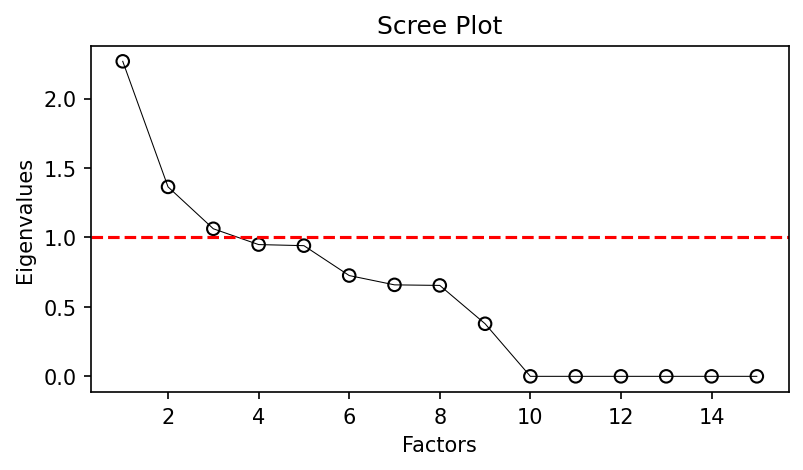

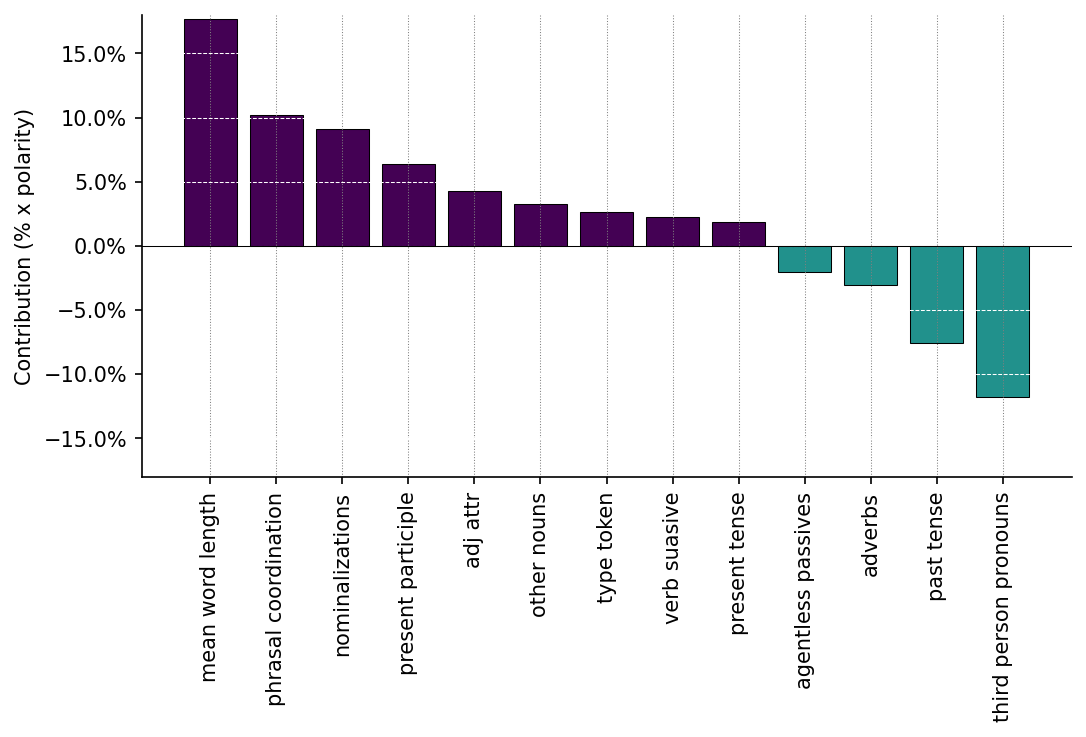

In [5]:
get_mda(features=features)